## **Imports**

In [1]:
import math
import os
import time
import pickle

import matplotlib.pyplot as plt
import numpy as np
import ot as pot
import torch
import torchdyn
from torchdyn.core import NeuralODE
from torchdyn.datasets import generate_moons

import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/mohammad/Documents/codes/diffusion_policy/")
sys.path.insert(0, str(PROJECT_ROOT))

from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *
from diffusion_policy.CFM.path.affine import CondOTProbPath
from diffusion_policy.model.diffusion.conditional_unet1d import ConditionalUnet1D
from diffusion_policy.CFM.cfm_model import CFMVectorField
from diffusion_policy.CFM.ode_solver import ODESolver
import copy
from diffusion_policy.model.common.lr_scheduler import get_scheduler
from diffusers.training_utils import EMAModel
from functools import partial
from diffusion_policy.CFM.path.affine import normal_log_prob

## **Functions**

In [2]:

def skewed_timestep_sample(num_samples: int, device: torch.device) -> torch.Tensor:
    P_mean = -1.2
    P_std = 1.2
    rnd_normal = torch.randn((num_samples,), device=device)
    sigma = (rnd_normal * P_std + P_mean).exp()
    time = 1 / (1 + sigma)
    time = torch.clip(time, min=0.0001, max=1.0)
    return time

def compute_nll(batch, solver, prior_std=1.0, exact_divergence = True):
    # normalize input
    global_cond = batch['obs']
    x1 = batch['action']
    time_grid = torch.tensor([1.0, 0.0])

    _, logp = solver.compute_likelihood(
        x_1=x1,
        log_p0=partial(normal_log_prob, std=prior_std),
        time_grid = time_grid,
        exact_divergence = exact_divergence,
        method="dopri5", 
        step_size=None,
        atol=1e-4,
        rtol=1e-4,
        return_intermediates=False,
        enable_grad=False,
        global_cond=global_cond
    )

    # action_normalizer = self.normalizer['action']
    # scale = action_normalizer.params_dict['scale'].to(
    #     device=x1.device,
    #     dtype=x1.dtype,
    # )
    # # The action normalizer applies an affine transform z = s * x + b.
    # # For a change of variables, the density in the original space gets an
    # # extra log-absolute-Jacobian term: sum(log |s|) per action coordinate.
    # # Since the transform is applied independently at each action step, the
    # # total Jacobian for a x_1ectory with T action steps is T * sum(log |s|).
    # log_abs_det = x1.shape[1] * torch.log(scale.abs()).sum()

    # logp = logp + log_abs_det

    # Normalize by the number of action dimensions so the reported NLL is
    # comparable across different action shapes and horizons.
    # num_dims = x1[0].numel()
    # nll_ = -logp.mean() / num_dims
    return -logp.mean()

def sample_target_distribution(size):
    if(DATASET=="moons"):
        return sample_moons(size)
    return p1.sample([size])



## Plots

In [15]:
def plot_all_training_losses(
    results,
    savepath=None,
    smoothing=200,
):
    """
    Plot training loss for all VF batch sizes on one figure.

    results[vf_batch_size] should contain:
        {
            "training_steps": [...],
            "training_losses": [...],
            "nll_steps": [...],
            "nll_scores": [...]
        }
    """

    fig, ax = plt.subplots()

    for vf_batch_size, result in results.items():

        steps = np.asarray(result["training_steps"])
        losses = np.asarray(result["training_losses"])

        if smoothing > 1 and len(losses) >= smoothing:
            kernel = np.ones(smoothing) / smoothing

            smoothed = np.convolve(
                losses,
                kernel,
                mode="valid",
            )

            smoothed_steps = steps[smoothing - 1:]

            ax.plot(
                smoothed_steps,
                smoothed,
                label=f"VF batch size = {vf_batch_size}",
            )
        else:
            ax.plot(
                steps,
                losses,
                label=f"VF batch size = {vf_batch_size}",
            )

    ax.set_xlabel("Training step")
    ax.set_ylabel("MSE loss")
    ax.set_title("Training loss")
    ax.grid(alpha=0.25)
    ax.legend()

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(
            savepath,
            dpi=200,
            bbox_inches="tight",
        )

    plt.grid(True)
    plt.show()
    plt.close(fig)


def plot_all_nlls(
    results,
    savepath=None,
):
    """
    Plot NLL for all VF batch sizes on one figure.
    """

    fig, ax = plt.subplots()

    for vf_batch_size, result in results.items():

        steps = np.asarray(result["nll_steps"])
        nll = np.asarray(result["nll_scores"])

        ax.plot(
            steps,
            nll,
            marker="o",
            markersize=3,
            label=f"VF batch size = {vf_batch_size}",
        )

    ax.set_xlabel("Training step")
    ax.set_ylabel("NLL / dimension")
    ax.set_title("Negative log-likelihood")
    #ax.grid(alpha=0.25)
    ax.legend()

    fig.tight_layout()
    plt.grid(True)

    if savepath is not None:
        fig.savefig(
            savepath,
            dpi=200,
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)

def plot_my_trajectories(solver, x1, plot_size):
    """Plot trajectories of some selected samples."""

    x_0 = torch.randn(plot_size, 1, 2)
    global_cond = torch.zeros(x_0.shape)
    global_cond = global_cond.flatten(1)

    time_grid=torch.tensor(
            [0.0, 1.0],
            device=x_0.device,
        )
    # integrate the ODE backwards in time
    x_1 = solver.sample(
        x_init=x_0,
        time_grid=time_grid,
        method="dopri5", 
        step_size=None,
        atol=1e-4,
        rtol=1e-4,
        return_intermediates=True,
        enable_grad=False,
        global_cond=global_cond
    )
    x_1 = x_1.flatten(2)
    x1 = x1.flatten(1)
    # evaluate FID score
    # x1_gen = x_1[-1,:,:]
    # fid_score = fid.fid_from_feats(x1_gen, x1_plot)
    n = 2000
    plt.figure(figsize=(6, 6))
    plt.scatter(x_1[0, :n, 0], x_1[0, :n, 1], s=10, alpha=0.6, c="black")
    plt.scatter(x_1[:, :n, 0], x_1[:, :n, 1], s=0.2, alpha=0.1, c="olive")
    plt.scatter(x_1[-1, :n, 0], x_1[-1, :n, 1], s=4, alpha=0.6, c="blue")
    plt.scatter(x1[:,0], x1[:,1], s=4, alpha=0.6, c="red")
    plt.legend(["Prior sample z(S)", "Flow", "z(0)", "Targets"])
    plt.grid(True)


## MLP

In [9]:
import torch
import torch.nn as nn


class MLPVectorField(nn.Module):
    """
    Simple MLP vector-field model with the same calling convention as
    the ConditionalUnet1D:

        model(x_t, t, global_cond=cond)

    Input:
        x_t:         [B, 1, dim]
        t:           [B]
        global_cond: [B, global_cond_dim]

    Output:
        [B, 1, dim]
    """

    def __init__(
        self,
        input_dim=2,
        global_cond_dim=2,
        hidden_dims=(128, 128, 128),
        time_embed_dim=64,
        embeding=True
    ):
        super().__init__()

        self.input_dim = input_dim
        self.global_cond_dim = global_cond_dim
        self.time_embed_dim = time_embed_dim
        self.embeding = embeding

        # Sinusoidal timestep embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(time_embed_dim, time_embed_dim),
            nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim),
        )

        layers = []
        if embeding:
            in_dim = input_dim + time_embed_dim + global_cond_dim
        else:
            in_dim = input_dim + 1 + global_cond_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.SELU())
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, input_dim))

        self.net = nn.Sequential(*layers)

    def timestep_embedding(self, t):
        """
        Sinusoidal embedding.

        t: [B]
        returns: [B, time_embed_dim]
        """
        half_dim = self.time_embed_dim // 2

        frequencies = torch.exp(
            -torch.log(torch.tensor(10000.0, device=t.device))
            * torch.arange(
                half_dim,
                device=t.device,
                dtype=t.dtype,
            )
            / max(half_dim - 1, 1)
        )

        args = t[:, None] * frequencies[None, :]

        embedding = torch.cat(
            [torch.sin(args), torch.cos(args)],
            dim=-1,
        )

        return embedding

    def forward(self, sample, timestep, global_cond=None):
        """
        Same interface as ConditionalUnet1D.

        x:
            [B, 1, input_dim]

        timestep:
            [B]

        global_cond:
            [B, global_cond_dim]

        returns:
            [B, 1, input_dim]
        """

        # [B, 1, D] -> [B, D]
        x_flat = sample.squeeze(1)

        if self.embeding:
            # Time embedding
            t_emb = self.timestep_embedding(timestep)
            t_emb = self.time_mlp(t_emb)
        else:
            t_emb = timestep.unsqueeze(1)
        
        # Global conditioning
        if global_cond is None:
            global_cond = torch.zeros(
                sample.shape[0],
                self.global_cond_dim,
                device=sample.device,
                dtype=sample.dtype,
            )
        #print (t_emb.shape)
        h = torch.cat(
            [x_flat, t_emb, global_cond],
            dim=-1,
        )
        
        out = self.net(h)

        # [B, D] -> [B, 1, D]
        return out.unsqueeze(1)

## **Training**

In [ ]:
savedir = "models/8gaussian-moons"
os.makedirs(savedir, exist_ok=True)

DATASET = "moons"
batch_size = 128
TRAINING_UPDATES = 30000
skewed_timesteps = False
VF_BATCH_SIZES = [0, 2048]
NTESTS = int(TRAINING_UPDATES / 30)
NETWORK = "Unet"         #MLP or Unet
EMBEDING = False

sigma = 0.01
dim = 2
test_size = 1024

# Distributions / flow matching
p0 = torch.distributions.MultivariateNormal(
    torch.zeros(dim),
    torch.eye(dim)
)
p1 = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(
        torch.tensor([1, 3])
    ),
    torch.distributions.Independent(
        torch.distributions.Normal(
            torch.tensor([
                [-5., -4],
                [6., 9.]
            ]),
            torch.tensor([
                [1., 3.],
                [2., 1.]
            ])
        ),
        1
    )
)

# Conditional Vector Field
CFM = CondOTProbPath(sigma=sigma)

# Test data
x1_test = sample_target_distribution(test_size)
x1_test = x1_test.unsqueeze(1)
cond_test = torch.zeros(
    test_size,
    dim
)

# Store results from every experiment
results = {}

# Run one complete training experiment per VF batch size
for vf_batch_size in VF_BATCH_SIZES:
    print("\n" + "=" * 60)
    print(f"Training with VF batch size = {vf_batch_size}")
    print("=" * 60)

    # IMPORTANT:
    # Reset step counter for every experiment
    global_step = 0

    # Model
    if NETWORK == "MLP":
        model = MLPVectorField(
            input_dim=dim,
            global_cond_dim=2,
            hidden_dims=(64, 64, 64),
            time_embed_dim=64,
            embeding=EMBEDING
        )
    elif NETWORK == "Unet":
        model = ConditionalUnet1D (input_dim=dim, 
                                   global_cond_dim = 2, 
                                   diffusion_step_embed_dim= 64, 
                                   down_dims= [64], 
                                   kernel_size= 1, 
                                   n_groups= 8, 
                                   cond_predict_scale= True)

    ema_model = copy.deepcopy(model)

    # Optimizer
    optimizer = torch.optim.Adam(
        model.parameters()
    )

    lr_scheduler = get_scheduler(
        "cosine",
        optimizer=optimizer,
        num_warmup_steps=500,
        num_training_steps=TRAINING_UPDATES,
        last_epoch=-1,
    )

    # EMA
    ema = EMAModel(
        model=ema_model,
        update_after_step=0,
        inv_gamma=1.0,
        power=0.75,
        min_value=0.0,
        max_value=0.9999,
    )

    # Conditioning
    cond = torch.zeros(batch_size,dim)

    # Loss
    MSE = torch.nn.MSELoss()

    # History
    training_steps = []
    training_losses = []

    nll_steps = []
    nll_scores = []

    # Training
    while global_step < TRAINING_UPDATES:

        x1_vf_batch = None

        # Sample source and target
        x1 = sample_target_distribution(batch_size)
        x0 = torch.randn(x1.shape, device=x1.device)

        # Additional samples for marginal VF estimation
        if vf_batch_size > 0:

            x1_vf_batch = sample_target_distribution(
                vf_batch_size
            )

            x1_vf_batch = x1_vf_batch.unsqueeze(1)


        # Sample time
        if skewed_timesteps:
            t = skewed_timestep_sample(
                x1.shape[0],
                device=x1.device
            )
        else:
            t = torch.rand(
                x1.shape[0],
                device=x1.device
            )

        # Add sequence dimension
        x0 = x0.unsqueeze(1)
        x1 = x1.unsqueeze(1)

        # Conditional flow matching
        out = CFM.sample(
            x0,
            x1,
            t,
            x1_vf_batch,
            prior_std=1.0,
            debug=False,
        )

        x_t = out.x_t
        u_t = out.dx_t

        # Predict vector field
        vt_pred = model(
            x_t,
            t,
            global_cond=cond,
        )

        # Loss
        loss = MSE(vt_pred,u_t)

        # Optimization
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        ema.step(model)

        # Logging
        training_steps.append(global_step)
        training_losses.append(loss.item())
        global_step += 1

        # NLL evaluation
        if global_step % NTESTS == 0 or global_step==1:
            model.eval()
            with torch.no_grad():
                batch = {
                    "obs": cond_test,
                    "action": x1_test,
                }

                # Construct from the current model
                vector_field = CFMVectorField(model)
                solver = ODESolver(vector_field)

                nll_score = compute_nll(batch,solver)
                nll_value = nll_score.item()

                # print(
                #     f"VF batch size = {vf_batch_size:4d} | "
                #     f"step = {global_step:5d} | "
                #     f"loss = {loss.item():.6f} | "
                #     f"NLL = {nll_value:.6f}"
                # )

                nll_steps.append(global_step)
                nll_scores.append(nll_value)
                if global_step==1 or global_step==TRAINING_UPDATES:
                    plot_my_trajectories (solver, x1_test, test_size)

            model.train()
    # Save results for this experiment
    results[vf_batch_size] = {
        "training_steps": training_steps,
        "training_losses": training_losses,
        "nll_steps": nll_steps,
        "nll_scores": nll_scores,
    }

    # Save individual experiment
    torch.save(
        results[vf_batch_size],
        os.path.join(
            savedir,
            f"results_vfbs_{vf_batch_size}.pt"
        )
    )
    print(
        f"Finished VF batch size = {vf_batch_size}"
    )
    
plot_all_training_losses(
    results,
    savepath=os.path.join(
        savedir,
        "training_loss_comparison.png"
    ),
    smoothing=200,
)

plot_all_nlls(
    results,
    savepath=os.path.join(
        savedir,
        "nll_comparison.png"
    ),
)


Training with VF batch size = 0
Finished VF batch size = 0

Training with VF batch size = 2048


torch.Size([2, 1024, 2])


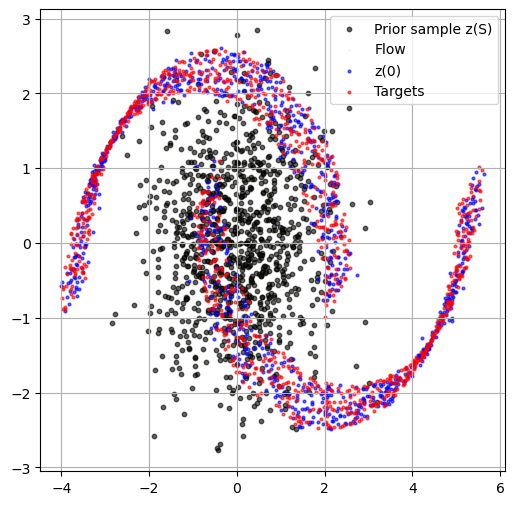

In [ ]:
def plot_my_trajectories(solver, x1, plot_size):
    """Plot trajectories of some selected samples."""

    x_0 = torch.randn(plot_size, 1, 2)
    global_cond = torch.zeros(x_0.shape)
    global_cond = global_cond.flatten(1)

    time_grid=torch.tensor(
            [0.0, 1.0],
            device=x_0.device,
        )
    # integrate the ODE backwards in time
    x_1 = solver.sample(
        x_init=x_0,
        time_grid=time_grid,
        method="dopri5", 
        step_size=None,
        atol=1e-4,
        rtol=1e-4,
        return_intermediates=True,
        enable_grad=False,
        global_cond=global_cond
    )
    x_1 = x_1.flatten(2)
    x1 = x1.flatten(1)
    print (x_1.shape)
    # evaluate FID score
    # x1_gen = x_1[-1,:,:]
    # fid_score = fid.fid_from_feats(x1_gen, x1_plot)
    n = 2000
    plt.figure(figsize=(6, 6))
    plt.scatter(x_1[0, :n, 0], x_1[0, :n, 1], s=10, alpha=0.6, c="black")
    plt.scatter(x_1[:, :n, 0], x_1[:, :n, 1], s=0.2, alpha=0.1, c="olive")
    plt.scatter(x_1[-1, :n, 0], x_1[-1, :n, 1], s=4, alpha=0.6, c="blue")
    plt.scatter(x1[:,0], x1[:,1], s=4, alpha=0.6, c="red")
    plt.legend(["Prior sample z(S)", "Flow", "z(0)", "Targets"])
    plt.grid(True)

plot_my_trajectories (solver, x1_test, test_size)